In [1]:
from h5 import HDFArchive
from triqs.atom_diag import AtomDiagComplex
from triqs.operators import n, c, c_dag
from itertools import product
from triqs.plot.mpl_interface import oplot

from sort import sort_states_full
from three_pt_corr_Ver2 import *

In [2]:
# # Hubbard dimer

# ####################
# # Input parameters #
# ####################

# beta = 2.0              # Inverse temperature
# eps = [-1.9, -2.1]      # Energy levels of the atoms
# t = 0.5                 # Hopping matrix element
# U = 4.0                 # Coulomb repulsion
# h_field = 0.05          # Magnetic field

# spin_names = ("up", "dn")
# atoms = (0, 1)

# # Number of bosonic Matsubara frequencies for susceptibility calculation
# n_iw = 10
# # Number of fermionic Matsubara frequencies for susceptibility calculation
# n_inu = 10

# # Block structure of \chi^3
# gf_struct = [['up', 4], ['dn', 4]]

# H = sum(e * n(s, a) for (a, e), s in product(zip(atoms, eps), spin_names))
# H += sum(-h_field * (n('up', a) - n('dn', a)) for a in atoms)
# H += U * sum(n('up', a) * n('dn', a) for a in atoms)
# H += t * sum((c_dag(sp, 0) * c(sp, 1) + c_dag(sp, 1) * c(sp, 0)) for sp in spin_names)
# # H += t * sum((c_dag(sp, 2) * c(sp, 3) + c_dag(sp, 3) * c(sp, 2)) for sp in spin_names)
# # H += t * sum((c_dag(sp, 0) * c(sp, 3) + c_dag(sp, 3) * c(sp, 0)) for sp in spin_names)

# fops = list(product(spin_names, atoms))

In [3]:
# 2x2 Hubbard plaquette

####################
# Input parameters #
####################

beta = 2.0              # Inverse temperature

eps = [-1.9, -2.1, -1.9, -2.1]  # On-site energies
t = 0.5                 # Nearest-neighbor hopping
U = 4.0                 # Coulomb repulsion
h_field = 0.05          # Magnetic field

spin_names = ("up", "dn")
atoms = (0, 1, 2, 3)

# Number of bosonic Matsubara frequencies for susceptibility calculation
n_iw = 10

# Number of fermionic Matsubara frequencies for susceptibility calculation
n_inu = 10

# Block structure of chi^3
gf_struct = [['up', 4], ['dn', 4]]

####################
# Hubbard Hamiltonian
####################

# On-site energies
H = sum(
    e * n(s, a)
    for (a, e), s in product(zip(atoms, eps), spin_names)
)

# Magnetic field
H += sum(
    -h_field * (n('up', a) - n('dn', a))
    for a in atoms
)

# On-site Hubbard interaction
H += U * sum(
    n('up', a) * n('dn', a)
    for a in atoms
)

# Nearest-neighbor hopping
#
#       0 ---- 1
#       |      |
#       |      |
#       2 ---- 3
#
H += t * sum(
    c_dag(sp, i) * c(sp, j)
    + c_dag(sp, j) * c(sp, i)
    for sp in spin_names
    for i, j in [
        (0, 1),  # top
        (1, 3),  # right
        (3, 2),  # bottom
        (2, 0),  # left
    ]
)

fops = list(product(spin_names, atoms))


In [4]:
ad = AtomDiagComplex(H, fops)

In [5]:
eigensys = sort_states_full(spin_names, atoms, ad)

states in subspace  0 : 
| 00110011 >
| 00110101 >
| 00110110 >
| 00111001 >
| 00111010 >
| 00111100 >
| 01010011 >
| 01010101 >
| 01010110 >
| 01011001 >
| 01011010 >
| 01011100 >
| 01100011 >
| 01100101 >
| 01100110 >
| 01101001 >
| 01101010 >
| 01101100 >
| 10010011 >
| 10010101 >
| 10010110 >
| 10011001 >
| 10011010 >
| 10011100 >
| 10100011 >
| 10100101 >
| 10100110 >
| 10101001 >
| 10101010 >
| 10101100 >
| 11000011 >
| 11000101 >
| 11000110 >
| 11001001 >
| 11001010 >
| 11001100 >
states in subspace  1 : 
| 00010111 >
| 00011011 >
| 00011101 >
| 00011110 >
| 00100111 >
| 00101011 >
| 00101101 >
| 00101110 >
| 01000111 >
| 01001011 >
| 01001101 >
| 01001110 >
| 10000111 >
| 10001011 >
| 10001101 >
| 10001110 >
states in subspace  2 : 
| 01110001 >
| 01110010 >
| 01110100 >
| 01111000 >
| 10110001 >
| 10110010 >
| 10110100 >
| 10111000 >
| 11010001 >
| 11010010 >
| 11010100 >
| 11011000 >
| 11100001 >
| 11100010 >
| 11100100 >
| 11101000 >
states in subspace  3 : 
| 00001111 >
sta

In [6]:
print(eigensys[1])

[[array([ 0.04818269-0.j, -0.11595807-0.j,  0.11024349-0.j, -0.46937346-0.j,
       -0.11595807-0.j,  0.05545555-0.j, -0.46937346-0.j,  0.1222049 -0.j,
       -0.11024349-0.j,  0.46937346-0.j, -0.04818269-0.j,  0.11595807-0.j,
        0.46937346-0.j, -0.1222049 -0.j,  0.11595807-0.j, -0.05545555-0.j]), ['00010111', '00011011', '00011101', '00011110', '00100111', '00101011', '00101101', '00101110', '01000111', '01001011', '01001101', '01001110', '10000111', '10001011', '10001101', '10001110']], np.float64(0.06605772025753076), 36]


In [7]:
%%time

ops = [(c_dag('up', 1), 'Fermion'),
       (c('up',0), 'Fermion'),
       (c('up', 0)*c_dag('up',1), 'Boson')]

corr = ThreePtCorr(ops = ops, hamiltonian = (ad, eigensys))

G_iw = corr.G_div_diff_iw(beta = beta, n_iw = [10,10])

CPU times: user 5min 6s, sys: 781 ms, total: 5min 7s
Wall time: 33.8 s


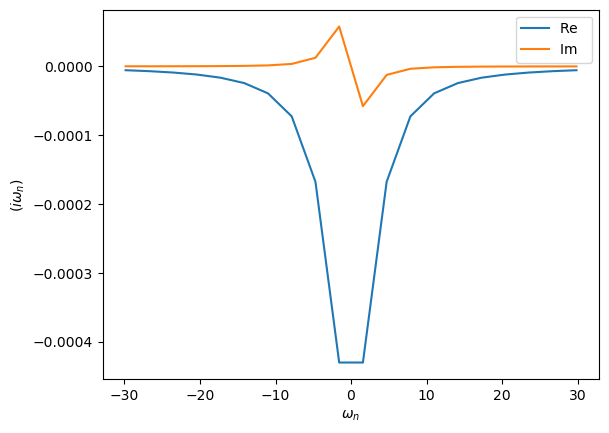

In [9]:
# G = Gf(mesh = iw_mesh2, target_shape = [])
# G.zero()

# for iw1 in iw_mesh2:
#     for iw2 in iw_mesh2:
#         G[iw1] += G_iw[iw1,iw2]

iw_mesh1 = MeshImFreq(beta = beta, statistic = 'Boson', n_iw = n_iw)
iw_mesh2 = MeshImFreq(beta = beta, statistic = 'Fermion', n_iw = n_inu)


G = Gf(mesh = iw_mesh2, target_shape = [])
G.zero()

for iw2 in iw_mesh2:
    for iw1 in iw_mesh2:
        G[iw2] += G_iw[iw1,iw2]


oplot(-G)


In [10]:
G_iw

Greens Function  with mesh Imaginary Freq Mesh with beta = 2, statistic = Fermion, n_iw = 10, positive_only = false, Imaginary Freq Mesh with beta = 2, statistic = Fermion, n_iw = 10, positive_only = false and target_shape (): 